# Exploratory Data Analysis

## 0.0 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 0.1 Seaborn's Grid Setup & Data Loading

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("../data/processed/vancouver_tech_postings.csv", parse_dates=["First Posting Date"])

In [4]:
print(df.shape)

(4105, 67)


In [5]:
df.head()

,WIC Job Location Snapshot ID,Job Title,Original Job Title,NOC 2016 Code,NOC 2016 Code Name,NOC21 Code,NOC21 Code Name,External Indicator,First Posting Date,Vacancy Count,...,Commission PER,Commission Type,Hours Per,Hours Minimum,Hours Maximum,Work Hours,Work Hours From Time,Work Hours To Time,Salary Min Annual,Salary Max Annual
0,15656146.0,information technology (IT) analyst,Lighting Specialist,2171.0,Information systems analysts and consultants,21222.0,Information systems specialists,1,2026-06-19,1,...,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,95000.0,95000.0
1,15668830.0,technical support engineer,NaN,2171.0,Information systems analysts and consultants,21222.0,Information systems specialists,1,2026-06-26,1,...,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,72000.0,85000.0
2,15606233.0,software developer,Mobile Security Professaional - Healthcare Sec...,2174.0,Computer programmers and interactive media dev...,21232.0,Software developers and programmers,1,2026-06-03,1,...,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,50700.0,50700.0
3,15612219.0,information technology (IT) analyst,Inside Sales Specialist,2171.0,Information systems analysts and consultants,21222.0,Information systems specialists,1,2026-06-04,1,...,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,54600.0,68250.0
4,15616226.0,Web developer,Backend Developer ( Nest.js Typescript),2175.0,Web designers and developers,21234.0,Web developers and programmers,1,2026-06-05,1,...,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,80000.0,120000.0


## 0.2 Fixing Code Related Columns (e.g. "WIC Job Location Snapshot ID","NOC 2016 Code", "NOC21 Code")

In [6]:
code_columns = ["WIC Job Location Snapshot ID","NOC 2016 Code", "NOC21 Code"]

In [7]:
for col in code_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

In [8]:
df[code_columns].head()

,WIC Job Location Snapshot ID,NOC 2016 Code,NOC21 Code
0,15656146,2171,21222
1,15668830,2171,21222
2,15606233,2174,21232
3,15612219,2171,21222
4,15616226,2175,21234


## 0.3 Checking  "Fist Posting Date" Data Type 

In [9]:
print(df["First Posting Date"].dtypes)

datetime64[us]


In [10]:
df.head()

,WIC Job Location Snapshot ID,Job Title,Original Job Title,NOC 2016 Code,NOC 2016 Code Name,NOC21 Code,NOC21 Code Name,External Indicator,First Posting Date,Vacancy Count,...,Commission PER,Commission Type,Hours Per,Hours Minimum,Hours Maximum,Work Hours,Work Hours From Time,Work Hours To Time,Salary Min Annual,Salary Max Annual
0,15656146,information technology (IT) analyst,Lighting Specialist,2171,Information systems analysts and consultants,21222,Information systems specialists,1,2026-06-19,1,...,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,95000.0,95000.0
1,15668830,technical support engineer,NaN,2171,Information systems analysts and consultants,21222,Information systems specialists,1,2026-06-26,1,...,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,72000.0,85000.0
2,15606233,software developer,Mobile Security Professaional - Healthcare Sec...,2174,Computer programmers and interactive media dev...,21232,Software developers and programmers,1,2026-06-03,1,...,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,50700.0,50700.0
3,15612219,information technology (IT) analyst,Inside Sales Specialist,2171,Information systems analysts and consultants,21222,Information systems specialists,1,2026-06-04,1,...,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,54600.0,68250.0
4,15616226,Web developer,Backend Developer ( Nest.js Typescript),2175,Web designers and developers,21234,Web developers and programmers,1,2026-06-05,1,...,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,80000.0,120000.0


In [11]:
df.tail()

,WIC Job Location Snapshot ID,Job Title,Original Job Title,NOC 2016 Code,NOC 2016 Code Name,NOC21 Code,NOC21 Code Name,External Indicator,First Posting Date,Vacancy Count,...,Commission PER,Commission Type,Hours Per,Hours Minimum,Hours Maximum,Work Hours,Work Hours From Time,Work Hours To Time,Salary Min Annual,Salary Max Annual
4100,<NA>,cloud operations manager,Operations Manager,213,Computer and information systems managers,20012,Computer and information systems managers,1,2024-07-30,1,...,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN
4101,<NA>,"manager, information systems",D365 Technical Project Manager,213,Computer and information systems managers,20012,Computer and information systems managers,1,2024-07-31,1,...,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN
4102,<NA>,informatics consultant,"Eyecare Consultant - West Vancouver, BC",2171,Information systems analysts and consultants,21222,Information systems specialists,1,2024-07-01,1,...,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN
4103,<NA>,QA (quality assurance) analyst - informatics,Quality Assurance Technician,2171,Information systems analysts and consultants,21222,Information systems specialists,1,2024-07-02,1,...,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN
4104,<NA>,software developer,NaN,2174,Computer programmers and interactive media dev...,21232,Software developers and programmers,0,2024-07-02,1,...,NaN,NaN,Week,35.0,35.0,No,NaN,NaN,85540.0,85540.0


In [12]:
print("Period to analyze ", df["First Posting Date"].min(), "to", df["First Posting Date"].max())

Period to analyze  2024-07-01 00:00:00 to 2026-06-30 00:00:00


In [13]:
print("Rows with unparseable dates:", df["First Posting Date"].isna().sum())

Rows with unparseable dates: 0


## 0.4 Trimming to a working subset of columns

In [14]:
working_cols = [
    "Job Title", "NOC21 Code", "NOC21 Code Name", "City",
    "First Posting Date", "Vacancy Count", "NAICS",
    "Salary Per", "Salary Minimum", "Salary Maximum",
    "Hours Minimum", "Hours Maximum",
    "Employment Type", "Employment Term", "Salary Min Annual", "Salary Max Annual"
]

In [15]:
df_eda = df[working_cols].copy()

In [16]:
df_eda.head()

,Job Title,NOC21 Code,NOC21 Code Name,City,First Posting Date,Vacancy Count,NAICS,Salary Per,Salary Minimum,Salary Maximum,Hours Minimum,Hours Maximum,Employment Type,Employment Term,Salary Min Annual,Salary Max Annual
0,information technology (IT) analyst,21222,Information systems specialists,Burnaby,2026-06-19,1,NaN,Year,95000.0,95000.0,NaN,NaN,Full time,NaN,95000.0,95000.0
1,technical support engineer,21222,Information systems specialists,Burnaby,2026-06-26,1,NaN,Year,72000.0,85000.0,NaN,NaN,Full time,Permanent employment,72000.0,85000.0
2,software developer,21232,Software developers and programmers,Vancouver,2026-06-03,1,NaN,Hour,26.0,26.0,NaN,NaN,Full time,NaN,50700.0,50700.0
3,information technology (IT) analyst,21222,Information systems specialists,Vancouver,2026-06-04,1,NaN,Hour,28.0,35.0,NaN,NaN,Full time,NaN,54600.0,68250.0
4,Web developer,21234,Web developers and programmers,Vancouver,2026-06-05,1,NaN,Year,80000.0,120000.0,NaN,NaN,Full time,NaN,80000.0,120000.0


## 1.0 Initial Analysis

### 1.1 Postings Volume per Month

In [17]:
monthly_counts = (df_eda.set_index("First Posting Date").resample("MS").size())

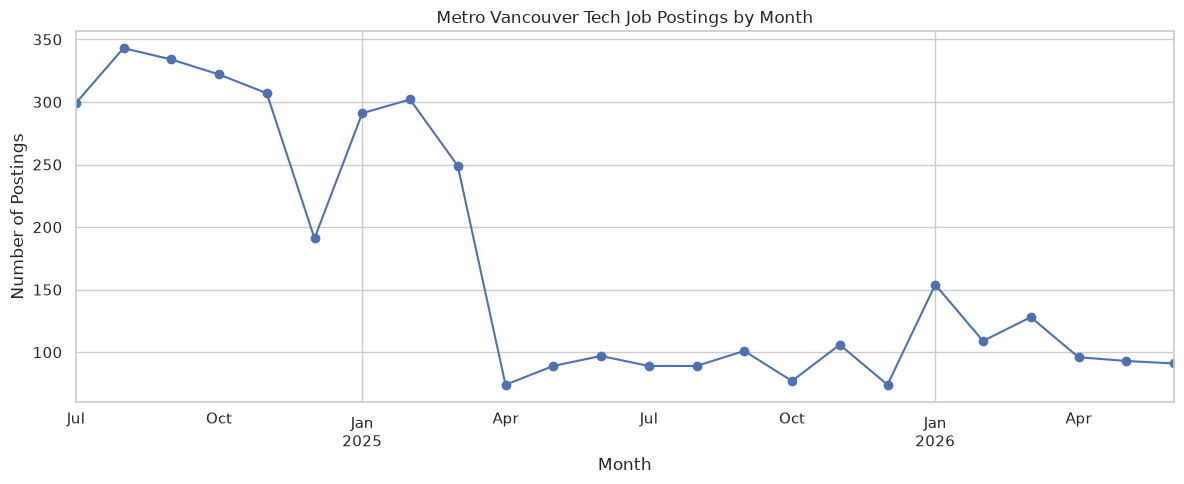

In [18]:
fig, ax = plt.subplots(figsize=(12,5))
monthly_counts.plot(ax=ax, marker="o")
ax.set_title("Metro Vancouver Tech Job Postings by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Postings")
plt.tight_layout()
plt.show()

Observation: It is possible to see an abrupt decrease in job postings in Vancouver's tech market since March 2025. Let's check if the trend is similar to the overall posting volume.

/tmp/ipykernel_26182/3892893857.py:5: DtypeWarning: Columns (0: Official Language) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv("../data/raw/combined_raw.csv")


Unparseable: 0 / 1735222


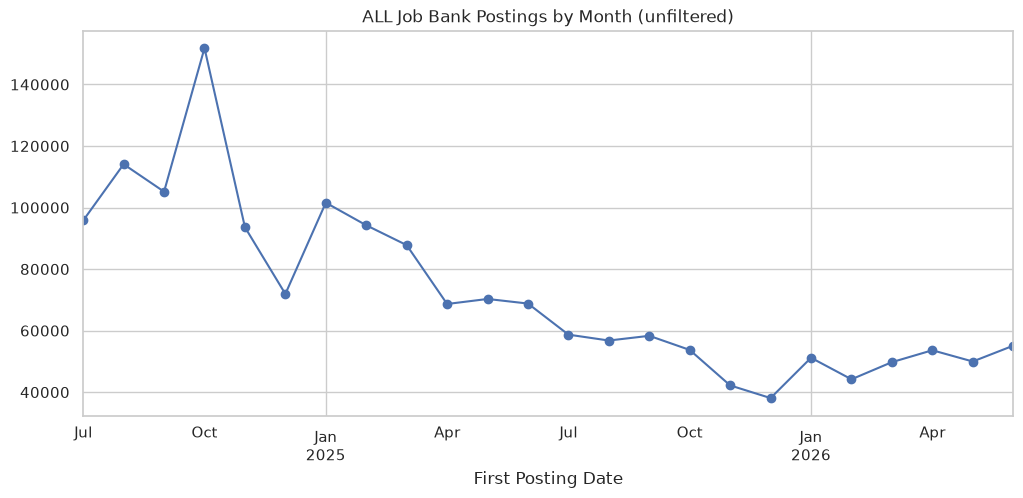

In [19]:
import sys
sys.path.insert(0, "..")
from src.data.build_dataset import parse_mixed_dates

raw = pd.read_csv("../data/raw/combined_raw.csv")
raw["First Posting Date"] = parse_mixed_dates(raw["First Posting Date"])

print("Unparseable:", raw["First Posting Date"].isna().sum(), "/", len(raw))

raw_monthly = raw.set_index("First Posting Date").resample("MS").size()

fig, ax = plt.subplots(figsize=(12, 5))
raw_monthly.plot(ax=ax, marker="o")
ax.set_title("ALL Job Bank Postings by Month (unfiltered)")
plt.show()

Observation: It is possible to see a similar decreasing trend, although there is a slightly less abrupt pattern in comparison to the tech market. Let's see how it looks if we break down the analysis by individual NOC code. This will help us understand whether it is broad-based or driven by one or two roles.

In [20]:
noc_monthly = (
    df_eda
    .set_index("First Posting Date")
    .groupby("NOC21 Code Name")
    .resample("MS")
    .size()
    .rename("count")
    .reset_index()
)

In [21]:
noc_monthly.head()

,NOC21 Code Name,First Posting Date,count
0,Business systems specialists,2024-07-01,6
1,Business systems specialists,2024-08-01,12
2,Business systems specialists,2024-09-01,12
3,Business systems specialists,2024-10-01,10
4,Business systems specialists,2024-11-01,12


In [22]:
nocs = noc_monthly["NOC21 Code Name"].unique()
palette = sns.color_palette("husl", len(nocs))

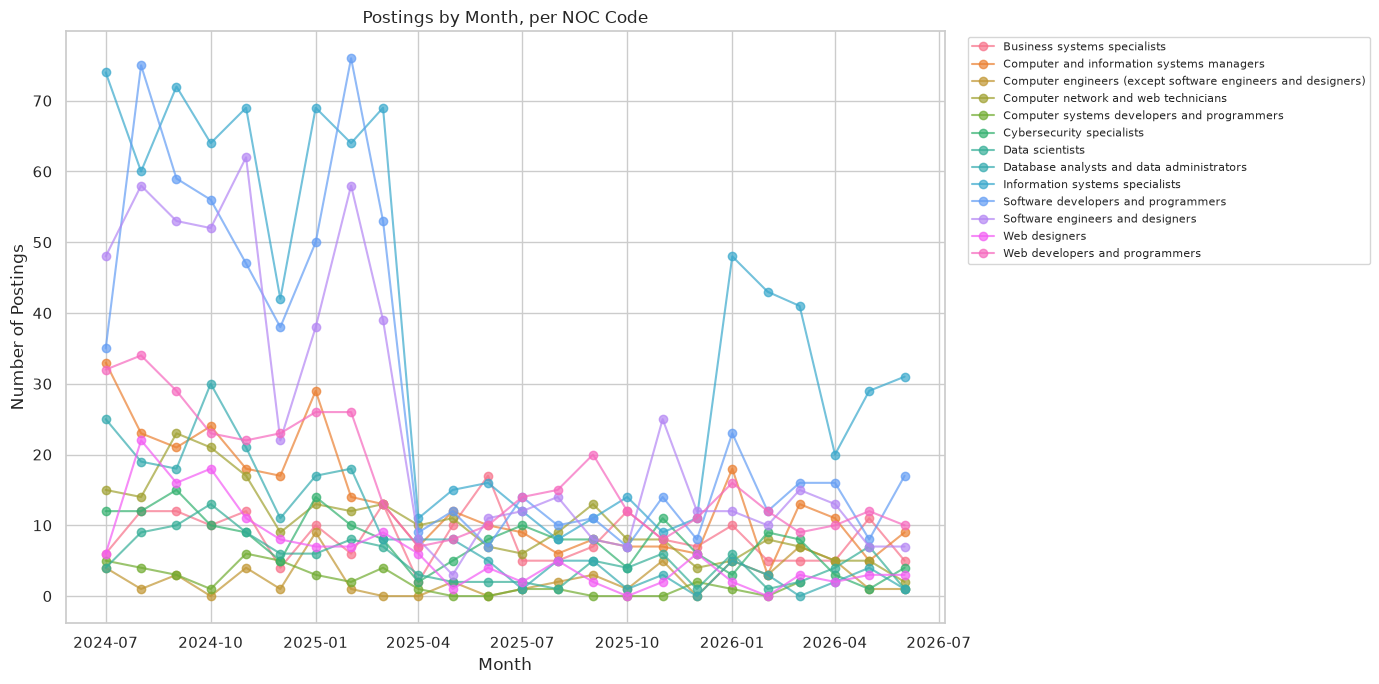

In [23]:
fig, ax = plt.subplots(figsize=(14, 7))
for color, (noc_name, group) in zip(palette, noc_monthly.groupby("NOC21 Code Name")):
    ax.plot(group["First Posting Date"], group["count"], marker="o", label=noc_name, color=color, alpha=0.7)

ax.set_title("Postings by Month, per NOC Code")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Postings")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Observation: Three NOCs in particular seem to have had the most notable dip in job postings in April 2025, compared to other NOCs: Software engineers and designers, Software developers and programmers, and Information systems specialists

Let's take a look at the counts of the month of March 2024.

In [24]:
noc_monthly[noc_monthly["First Posting Date"] == "2025-03-01"].sort_values("count", ascending=False)

,NOC21 Code Name,First Posting Date,count
197,Information systems specialists,2025-03-01,69
221,Software developers and programmers,2025-03-01,53
245,Software engineers and designers,2025-03-01,39
32,Computer and information systems managers,2025-03-01,13
8,Business systems specialists,2025-03-01,13
80,Computer network and web technicians,2025-03-01,13
293,Web developers and programmers,2025-03-01,13
269,Web designers,2025-03-01,9
125,Cybersecurity specialists,2025-03-01,8
173,Database analysts and data administrators,2025-03-01,8


Let's take a look at the count of the month of April 2024.

In [25]:
noc_monthly[noc_monthly["First Posting Date"] == "2025-04-01"].sort_values("count", ascending=False)

,NOC21 Code Name,First Posting Date,count
198,Information systems specialists,2025-04-01,11
81,Computer network and web technicians,2025-04-01,10
222,Software developers and programmers,2025-04-01,9
174,Database analysts and data administrators,2025-04-01,8
246,Software engineers and designers,2025-04-01,8
294,Web developers and programmers,2025-04-01,7
33,Computer and information systems managers,2025-04-01,7
270,Web designers,2025-04-01,6
150,Data scientists,2025-04-01,3
9,Business systems specialists,2025-04-01,2


Let's compare their typical ranking to see whether April 2025 is business-as-usual or something shifted.

In [26]:
avg_rank = (
    noc_monthly
    .assign(month_rank=noc_monthly.groupby("First Posting Date")["count"].rank(ascending=False))
    .groupby("NOC21 Code Name")["month_rank"]
    .mean()
    .sort_values()
)
print(avg_rank)

NOC21 Code Name
Information systems specialists                                  1.708333
Software developers and programmers                              2.729167
Software engineers and designers                                 3.645833
Web developers and programmers                                   3.916667
Computer and information systems managers                        5.479167
Computer network and web technicians                             6.375000
Business systems specialists                                     7.416667
Cybersecurity specialists                                        8.020833
Database analysts and data administrators                        8.437500
Web designers                                                    9.729167
Data scientists                                                 10.020833
Computer engineers (except software engineers and designers)    11.291667
Computer systems developers and programmers                     12.119048
Name: month_rank, dtyp

Observation: We see that they are consistently the NOCs with the top number of roles per month. This was not a special event for them specifically, but rather a market-wide dip that is most visible in the biggest categories.

Let's take a look at the percentaje of change from March 2025 to April 2025, to identify the NOCs that dropped the most.

In [27]:
# % change from March 2025 to April 2025, per NOC
pivot = noc_monthly.pivot(index="First Posting Date", columns="NOC21 Code Name", values="count")
pct_change = pivot.pct_change().loc["2025-04-01"].sort_values()
print(pct_change)

NOC21 Code Name
Business systems specialists                                   -0.846154
Information systems specialists                                -0.840580
Software developers and programmers                            -0.830189
Software engineers and designers                               -0.794872
Cybersecurity specialists                                      -0.750000
Computer systems developers and programmers                    -0.750000
Data scientists                                                -0.571429
Computer and information systems managers                      -0.461538
Web developers and programmers                                 -0.461538
Web designers                                                  -0.333333
Computer network and web technicians                           -0.230769
Database analysts and data administrators                       0.000000
Computer engineers (except software engineers and designers)         NaN
Name: 2025-04-01 00:00:00, dtype: f

Observation: Taking a look at percentage change, it is possible to see that the NOCs with the proportionally steepest drops in April 2025 were actually Business systems specialists (-84.61%), Information systems specialists (-84.05%), and Software developers and programmers (-83.01%).

This shows the visual dip in the top three highest-volume NOCs was partly a scale effect; the sharpest proportional declines were spread across a broader set of roles.

## 1.2 Salary Analysis

First, let's normalize the salaries to annual values.

Let's check the shape of the data.

In [28]:
print(df_eda.shape)

(4105, 16)


Let's check the unique values of the "Salary Per" column.

In [29]:
df_eda["Salary Per"].unique()

<StringArray>
['Year', 'Hour', 'Month', 'Bi-weekly', 'Week', nan]
Length: 6, dtype: str

Let's check the count of valuest that fall within each category.

In [30]:
df_eda["Salary Per"].value_counts(dropna=False)

Salary Per
Hour         1620
NaN          1281
Year         1076
Month          77
Bi-weekly      50
Week            1
Name: count, dtype: int64

Let's visualize the counts by "Per Salary" type.

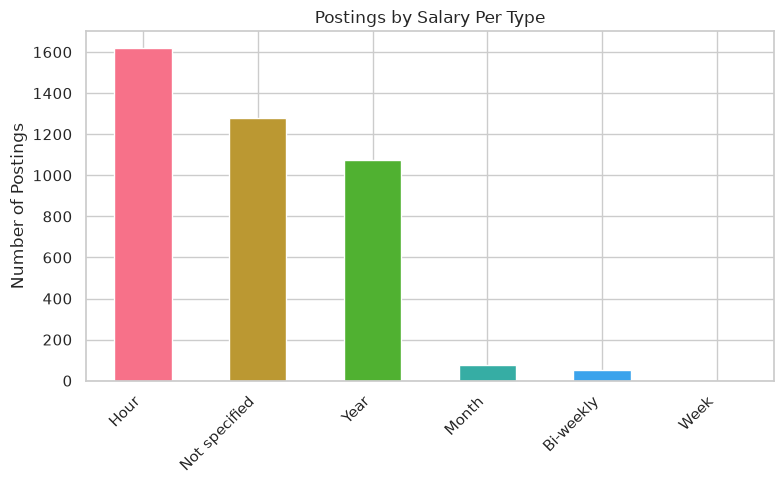

In [31]:
salary_per_counts = (
    df_eda["Salary Per"]
    .fillna("Not specified")
    .value_counts()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
salary_per_counts.plot(kind="bar", ax=ax, color=sns.color_palette("husl", len(salary_per_counts)))
ax.set_title("Postings by Salary Per Type")
ax.set_ylabel("Number of Postings")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Now, let's take a look at the values where the "Salary Per" type was not specified. We want to know if any of these rows have a salary or if they are simply blank across the board.

In [32]:
missing_per = df_eda[df_eda["Salary Per"].isna()]
print("Rows with Salary Per missing:", len(missing_per))
print()
print("Of those, Salary Minimum populated:", missing_per["Salary Minimum"].notna().sum())
print("Of those, Salary Maximum populated:", missing_per["Salary Maximum"].notna().sum())

Rows with Salary Per missing: 1281

Of those, Salary Minimum populated: 0
Of those, Salary Maximum populated: 0


This are good news, since it means that they simply didn't post the salary for these job positions.

In [33]:
#df_eda["Salary Min Annual"] = df_eda.apply(lambda r: to_annual(r, "Salary Minimum"), axis=1)
#df_eda["Salary Max Annual"] = df_eda.apply(lambda r: to_annual(r, "Salary Maximum"), axis=1)
print(df[["Salary Min Annual", "Salary Max Annual"]].describe())

       Salary Min Annual  Salary Max Annual
count       2.824000e+03       2.824000e+03
mean        2.289178e+05       2.497047e+05
std         5.321018e+06       5.685500e+06
min         1.300000e+02       1.900000e+02
25%         6.510920e+04       7.200720e+04
50%         8.059375e+04       9.000000e+04
75%         9.880000e+04       1.120080e+05
max         2.067000e+08       2.325180e+08


Let's take a look at the dataset's descriptive statistics.

In [34]:
df_eda[["Salary Min Annual", "Salary Max Annual"]].describe()

,Salary Min Annual,Salary Max Annual
count,2.824000e+03,2.824000e+03
mean,2.289178e+05,2.497047e+05
std,5.321018e+06,5.685500e+06
min,1.300000e+02,1.900000e+02
25%,6.510920e+04,7.200720e+04
50%,8.059375e+04,9.000000e+04
75%,9.880000e+04,1.120080e+05
max,2.067000e+08,2.325180e+08


Let's do an initial check for possible outliers in the dataset.

In [35]:
implausible = df_eda[
    (df_eda["Salary Max Annual"] < 10000) | (df_eda["Salary Max Annual"] > 500000)
]
print(f"Implausible rows: {len(implausible)} / {df_eda['Salary Max Annual'].notna().sum()}")
print()
print(implausible[["Job Title", "Salary Per", "Salary Minimum", "Salary Maximum", "Salary Max Annual"]].head(10))

Implausible rows: 12 / 2824

                                              Job Title Salary Per  \
166   electronic commerce (e-commerce) Web site deve...       Year   
186                                       Web developer       Year   
291                 information technology (IT) analyst       Year   
314                                  software developer       Year   
494                                   software engineer      Month   
543                                   software engineer      Month   
691                                   software engineer      Month   
891                                     systems analyst  Bi-weekly   
1716                                 back-end developer      Month   
2144                          computer programs manager       Hour   

      Salary Minimum  Salary Maximum  Salary Max Annual  
166           4000.0          6000.0             6000.0  
186            160.0           210.0              210.0  
291           2000.0      

With this information, let's create a subset for the salary analysis.

In [36]:
# Include valid postings with a max annual salary of 10000 and 500000 and not nan
plausible_mask = (
    df_eda["Salary Max Annual"].between(10000, 500000, inclusive="both")
    | df_eda["Salary Max Annual"].isna()
)

df_salary = df_eda[plausible_mask & df_eda["Salary Max Annual"].notna()].copy()
print(f"Salary analysis dataset: {len(df_salary)} rows")

Salary analysis dataset: 2812 rows


In [37]:
df_salary[["Salary Min Annual", "Salary Max Annual"]].describe()

,Salary Min Annual,Salary Max Annual
count,2812.000000,2812.000000
mean,84485.567813,95300.738435
std,27736.664812,34192.693408
min,14560.000000,14560.000000
25%,65145.600000,72009.600000
50%,80080.000000,90000.000000
75%,98280.000000,112008.000000
max,250000.000000,323050.000000


Now that we have a cleaner dataset, let's take a look at the distribution of the salary data.

First, we will create a anual salary midpoint.

In [38]:
df_salary["Salary Midpoint Annual"] = (
    df_salary["Salary Min Annual"] + df_salary["Salary Max Annual"]
) / 2

Next, we will order NOC codes by median salary in descending order.

In [39]:
noc_order = (
    df_salary.groupby("NOC21 Code Name")["Salary Midpoint Annual"]
    .median()
    .sort_values(ascending=False)
    .index
)

/tmp/ipykernel_26182/3281743620.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


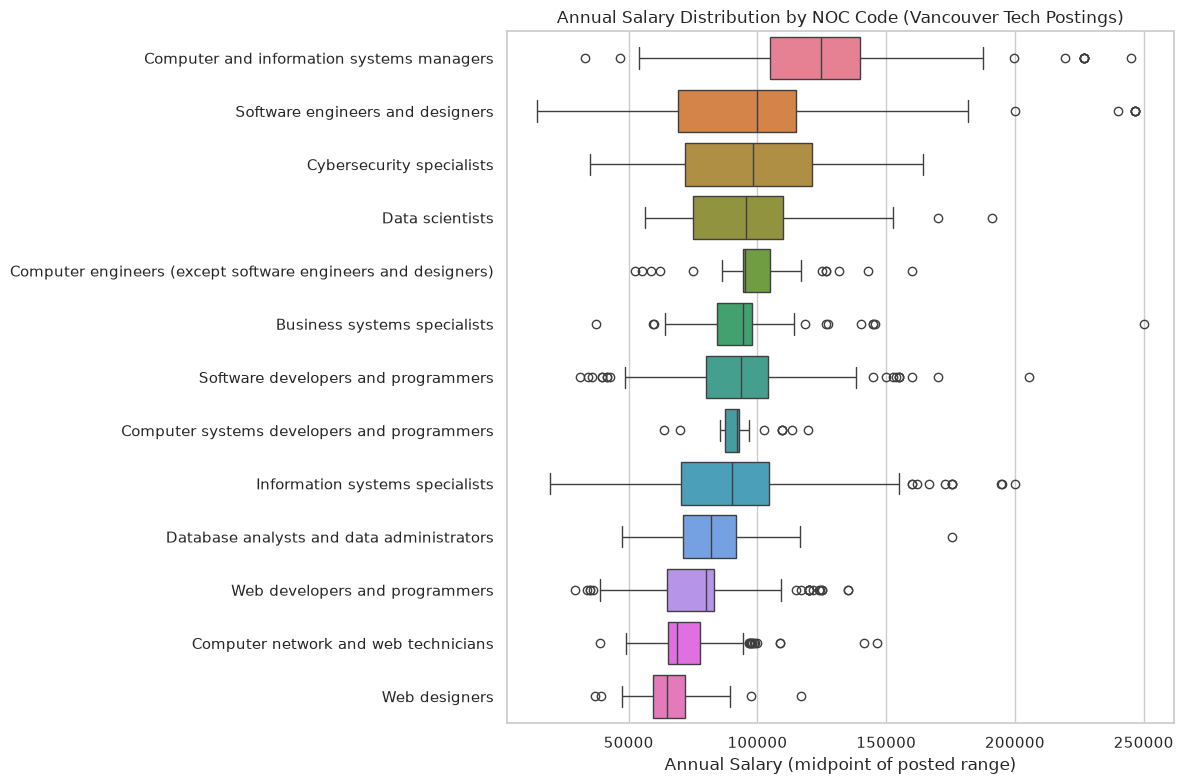

In [40]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.boxplot(
    data=df_salary,
    y="NOC21 Code Name",
    x="Salary Midpoint Annual",
    order=noc_order,
    palette="husl",
    ax=ax,
)
ax.set_title("Annual Salary Distribution by NOC Code (Vancouver Tech Postings)")
ax.set_xlabel("Annual Salary (midpoint of posted range)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Let's check the NOC counts in our subset.

In [41]:
counts = df_salary["NOC21 Code Name"].value_counts()
print(counts.reindex(noc_order))

NOC21 Code Name
Computer and information systems managers                       242
Software engineers and designers                                310
Cybersecurity specialists                                       156
Data scientists                                                  85
Computer engineers (except software engineers and designers)     49
Business systems specialists                                    192
Software developers and programmers                             359
Computer systems developers and programmers                      37
Information systems specialists                                 500
Database analysts and data administrators                       133
Web developers and programmers                                  370
Computer network and web technicians                            237
Web designers                                                   142
Name: count, dtype: int64


We see outliers (the values Q1 minus 1.5×IQR on the low end, Q3 plus 1.5×IQR on the high end). This is expected since various roles can fall within the same NOC and there are different levels within the same position (junior/senior/lead/architect/staff). Let's check whic NOCs have the most extreme outliers.

In [42]:
# For each NOC, find rows sitting outside 1.5x IQR — the boxplot's own outlier definition
def flag_outliers(group):
    q1, q3 = group["Salary Midpoint Annual"].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return group[(group["Salary Midpoint Annual"] < lower) | (group["Salary Midpoint Annual"] > upper)]

In [43]:
outliers = df_salary.groupby("NOC21 Code Name", group_keys=False)[df_salary.columns].apply(flag_outliers)

In [44]:
print(f"Total outlier postings: {len(outliers)}")
print()
print(outliers["NOC21 Code Name"].value_counts())
print()
print(f"Percentage of outliers: {np.round((len(outliers)/len(df_salary))*100, 2)}%")

Total outlier postings: 118

NOC21 Code Name
Web developers and programmers                                  20
Software developers and programmers                             18
Computer network and web technicians                            14
Business systems specialists                                    11
Computer and information systems managers                       11
Computer engineers (except software engineers and designers)    11
Information systems specialists                                 11
Computer systems developers and programmers                      8
Software engineers and designers                                 7
Web designers                                                    4
Data scientists                                                  2
Database analysts and data administrators                        1
Name: count, dtype: int64

Percentage of outliers: 4.2%


Let's take a closer look at these outliers.

In [45]:
print("=== Highest outliers ===")
print(outliers.sort_values("Salary Midpoint Annual", ascending=False)[
    ["Job Title", "NOC21 Code Name", "Salary Per", "Salary Minimum", "Salary Maximum", "Salary Midpoint Annual"]
].head(15))

print()
print("=== Lowest outliers ===")
print(outliers.sort_values("Salary Midpoint Annual")[
    ["Job Title", "NOC21 Code Name", "Salary Per", "Salary Minimum", "Salary Maximum", "Salary Midpoint Annual"]
].head(15))

=== Highest outliers ===
                                           Job Title  \
2378         systems business re-engineering analyst   
81                        computer software engineer   
1042                      computer software engineer   
330                       computer software engineer   
945                       computer software engineer   
636                       computer software engineer   
709          information systems operations director   
360   artificial intelligence (ai) software engineer   
331                                 computer manager   
1011                                computer manager   
150                                 computer manager   
1041                                computer manager   
635                                 computer manager   
893                                 computer manager   
310                           director of technology   

                                NOC21 Code Name Salary Per  Salary Minimum  \


In [46]:
print(df_salary[df_salary["Job Title"] == "Web developer"][
    ["Job Title", "Salary Minimum", "Hours Minimum", "Hours Maximum"]
].drop_duplicates())

          Job Title  Salary Minimum  Hours Minimum  Hours Maximum
4     Web developer        80000.00            NaN            NaN
41    Web developer        90000.00            NaN            NaN
142   Web developer        55000.00            NaN            NaN
198   Web developer           43.00           30.0           30.0
211   Web developer           18.25           35.0           40.0
...             ...             ...            ...            ...
3602  Web developer           50.00           40.0           40.0
3619  Web developer           33.00           40.0           40.0
3750  Web developer           30.00           37.5           37.5
3805  Web developer           34.38           35.0           35.0
3848  Web developer        63000.00            NaN            NaN

[76 rows x 4 columns]


In [47]:
web_dev_45 = df_salary[(df_salary["Job Title"] == "Web developer") & (df_salary["Salary Minimum"] == 45.00)]
print(web_dev_45[["Job Title", "Salary Minimum", "Salary Maximum", "Hours Minimum", "Hours Maximum", "Salary Midpoint Annual"]])

          Job Title  Salary Minimum  Salary Maximum  Hours Minimum  \
1030  Web developer            45.0            45.0          176.0   
1181  Web developer            45.0            45.0          176.0   
1327  Web developer            45.0            45.0          176.0   
1724  Web developer            45.0            45.0          176.0   
2179  Web developer            45.0            45.0          176.0   

      Hours Maximum  Salary Midpoint Annual  
1030          176.0                 87750.0  
1181          176.0                 87750.0  
1327          176.0                 87750.0  
1724          176.0                 87750.0  
2179          176.0                 87750.0  
